Some text will follow

In [ ]:
# packages
# file structure
import os
import pathlib
import glob
# vector and raster data
import geopandas as gpd
import pandas as pd
import rioxarray as rxr
import xarray as xr
# arrays
import numpy as np
# plotting
import holoviews as hv
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
# open street map
from osmnx import features as osm
import osmnx as ox
# earthpy
import earthpy
import earthpy.api.appeears as eaapp

In [14]:
# Set up a project and folder for data using earthpy
project = earthpy.Project("Everglades Vegetation", dirname = 'ndvi_project')

In [15]:
# Search for RMNP using OpenStreetMaps
everglades_gdf = ox.geocode_to_gdf(
    'Everglades National Park')

# Check it out
everglades_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-81.52053 25.83264, -81.52048 25.818...",-81.520526,24.851129,-80.388994,25.891513,416088476,relation,2163707,25.367944,-80.878307,boundary,protected_area,25,0.540428,protected_area,Everglades National Park,"Everglades National Park, Florida, 34138, Unit..."


<Axes: >

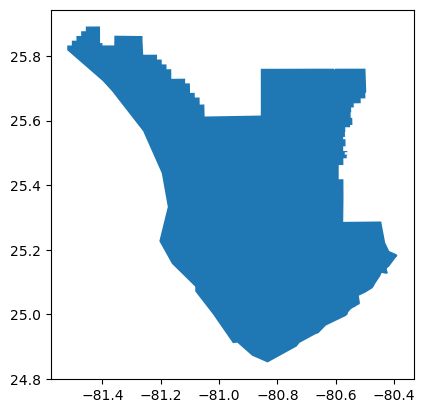

In [16]:
# Make a plot of the boundary
everglades_gdf.plot()

In [17]:
# Initialize AppeearsDownloader for MODIS NDVI data
# Set parameters
ndvi_downloader = eaapp.AppeearsDownloader(

    # Give the download a name
    download_key = "everglades_ndvi",

    # Tell it to put the data in the project directory already defined
    project = project,

    # Specify the MODIS product
    product = 'MOD13Q1.061',
    layer = '_250m_16_days_NDVI',

    # Set a start date and end data
    start_date = "04-01",
    end_date = "09-30",

    # Recurring meaning we want to download those dates over multiple years
    recurring = True,

    # Specify the range of years of interest
    year_range = [2000, 2024],

    # Specify the polygon we want to get NDVI data for
    polygon = everglades_gdf
)

In [18]:
# Download the prepared download
ndvi_downloader.download_files(cache=True)

Credentials found using 'env' backend.
